# 06. The crisis windows
The study compares the models in **calm** times and in **five crisis windows**. Here we label every day with its window, measure how wild each window was, and draw the main picture of the data.

* **Needs:** `work/dataset.csv`. **Makes:** `work/dataset.csv` again, with a new column `window`.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [2]:
from pandas import read_csv
dataset = read_csv(folder + 'work/dataset.csv', index_col=0, parse_dates=True)
print(dataset.shape)

(5835, 16)


## The windows

| Window | From | To | Origin |
|---|---|---|---|
| Global Financial Crisis (GFC) | 9 Aug 2007 (BNP Paribas freezes funds) | 9 Mar 2009 (US market bottom) | US banking, Irish property crash at the same time |
| Irish sovereign debt crisis | 23 Apr 2010 (Greece asks for help) | 26 Jul 2012 (Draghi: 'whatever it takes') | euro-area debt and Irish banks |
| COVID-19 | 19 Feb 2020 | 30 Jun 2020 | a health shock from outside the financial system |
| War / energy shock 2022 | 10 Feb 2022 | 31 Oct 2022 | war in Ukraine, energy prices, interest rates |
| Brexit referendum | 1 Jun 2016 | 31 Jul 2016 | a UK political shock |

**Important:** the window labels are used only to **report** the results afterwards. The models never see them.

In [3]:
dataset['window'] = 'calm'
dataset.loc['2007-08-09':'2009-03-09', 'window'] = 'Global Financial Crisis'
dataset.loc['2010-04-23':'2012-07-26', 'window'] = 'Irish sovereign debt crisis'
dataset.loc['2020-02-19':'2020-06-30', 'window'] = 'COVID-19'
dataset.loc['2022-02-10':'2022-10-31', 'window'] = 'War / energy shock 2022'
dataset.loc['2016-06-01':'2016-07-31', 'window'] = 'Brexit referendum'
dataset.loc[:'2023-08-31', 'window'].value_counts()

window
calm                           3948
Irish sovereign debt crisis     574
Global Financial Crisis         402
War / energy shock 2022         185
COVID-19                         92
Brexit referendum                42
Name: count, dtype: int64

## How wild was each window?
The median annualised volatility of the next week, in each window (`groupby` = do the calculation separately for each group).

In [4]:
from numpy import sqrt
dataset['vol_annual'] = sqrt(dataset['rv5_fwd'] * 252 / 5)
(dataset.loc[:'2023-08-31'].groupby('window')['vol_annual'].median() * 100).round(1)

window
Brexit referendum              24.9
COVID-19                       35.9
Global Financial Crisis        34.2
Irish sovereign debt crisis    18.2
War / energy shock 2022        23.3
calm                           12.9
Name: vol_annual, dtype: float64

## The largest fall inside each window (drawdown)
`cummax()` gives the highest price **so far**; dividing the price by it shows how far below its peak the market is.

In [5]:
gfc = dataset.loc['2007-08-09':'2009-03-09', 'Close']
drawdown = gfc / gfc.cummax() - 1
print('GFC largest fall:', round(drawdown.min() * 100, 1), '%')

GFC largest fall: -78.0 %


In [6]:
irish = dataset.loc['2010-04-23':'2012-07-26', 'Close']
print('Irish crisis largest fall:', round((irish / irish.cummax() - 1).min() * 100, 1), '%')
covid = dataset.loc['2020-02-19':'2020-06-30', 'Close']
print('COVID largest fall:', round((covid / covid.cummax() - 1).min() * 100, 1), '%')
war = dataset.loc['2022-02-10':'2022-10-31', 'Close']
print('2022 largest fall:', round((war / war.cummax() - 1).min() * 100, 1), '%')
brexit = dataset.loc['2016-06-01':'2016-07-31', 'Close']
print('Brexit largest fall:', round((brexit / brexit.cummax() - 1).min() * 100, 1), '%')

Irish crisis largest fall: -32.3 %
COVID largest fall: -39.8 %
2022 largest fall: -27.5 %
Brexit largest fall: -18.2 %


## The main picture of the data

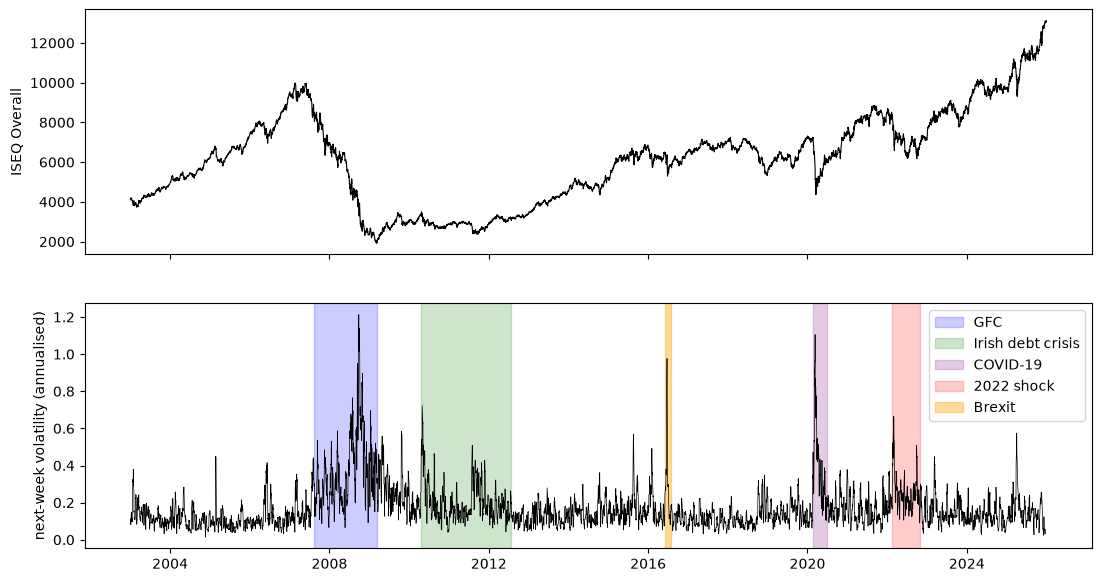

In [7]:
import matplotlib.pyplot as plt
from pandas import to_datetime
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax1.plot(dataset['Close'], color='black', linewidth=0.8)
ax1.set_ylabel('ISEQ Overall')
ax2.plot(dataset['vol_annual'], color='black', linewidth=0.5)
ax2.set_ylabel('next-week volatility (annualised)')
ax2.axvspan(to_datetime('2007-08-09'), to_datetime('2009-03-09'), color='blue', alpha=0.2, label='GFC')
ax2.axvspan(to_datetime('2010-04-23'), to_datetime('2012-07-26'), color='green', alpha=0.2, label='Irish debt crisis')
ax2.axvspan(to_datetime('2020-02-19'), to_datetime('2020-06-30'), color='purple', alpha=0.2, label='COVID-19')
ax2.axvspan(to_datetime('2022-02-10'), to_datetime('2022-10-31'), color='red', alpha=0.2, label='2022 shock')
ax2.axvspan(to_datetime('2016-06-01'), to_datetime('2016-07-31'), color='orange', alpha=0.4, label='Brexit')
ax2.legend()
plt.show()

In [8]:
dataset = dataset.drop(columns=['vol_annual'])
dataset.to_csv(folder + 'work/dataset.csv')
print('saved with the window column')

saved with the window column
